In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
file_path="/content/drive/MyDrive/student_exam_data.csv"

In [7]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report )

In [8]:
# Display first 5 rows
df = pd.read_csv(file_path)
print("First 5 Rows:")
print(df.head())

First 5 Rows:
   Study Hours  Previous Exam Score  Pass/Fail
0     4.370861            81.889703          0
1     9.556429            72.165782          1
2     7.587945            58.571657          0
3     6.387926            88.827701          1
4     2.404168            81.083870          0


In [9]:
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Records:", df.duplicated().sum())
df = df.drop_duplicates()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Study Hours          500 non-null    float64
 1   Previous Exam Score  500 non-null    float64
 2   Pass/Fail            500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB
None

Missing Values:
Study Hours            0
Previous Exam Score    0
Pass/Fail              0
dtype: int64

Duplicate Records: 0


In [10]:
print("\nDescriptive Statistics:")
print(df.describe())
print("\nPass/Fail Count:")
print(df['Pass/Fail'].value_counts())



Descriptive Statistics:
       Study Hours  Previous Exam Score   Pass/Fail
count   500.000000           500.000000  500.000000
mean      5.487055            68.917084    0.368000
std       2.688196            17.129607    0.482744
min       1.045554            40.277921    0.000000
25%       3.171517            53.745955    0.000000
50%       5.618474            68.309294    0.000000
75%       7.805124            83.580209    1.000000
max       9.936683            99.983060    1.000000

Pass/Fail Count:
Pass/Fail
0    316
1    184
Name: count, dtype: int64


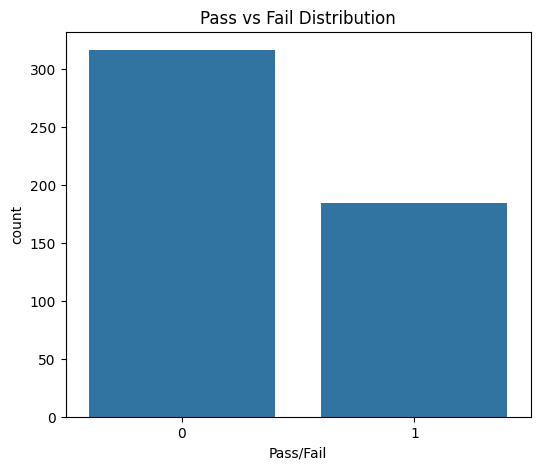

In [11]:
# Pass vs Fail Distribution
plt.figure(figsize=(6,5))
sns.countplot(x='Pass/Fail', data=df)
plt.title("Pass vs Fail Distribution")
plt.show()

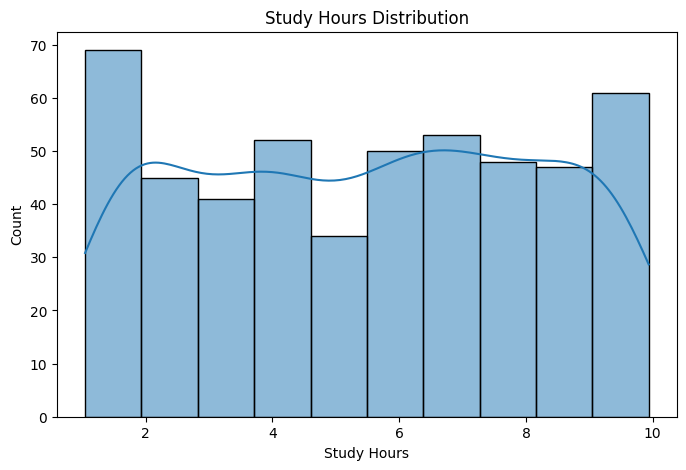

In [12]:
# Study Hours Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Study Hours'], bins=10, kde=True)
plt.title("Study Hours Distribution")
plt.show()

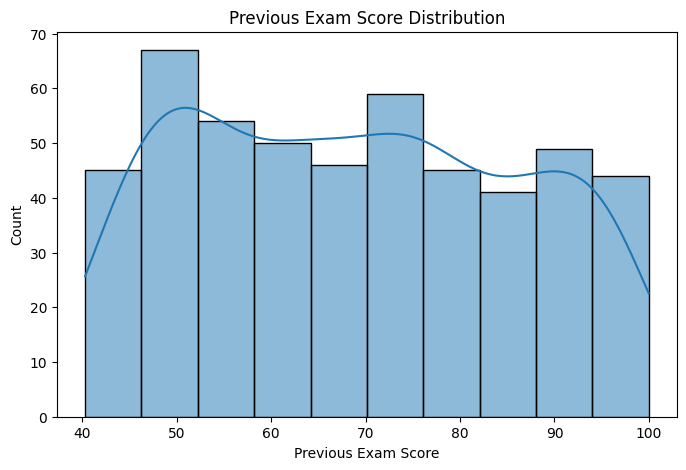

In [13]:
# Final Exam Score Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Previous Exam Score'], bins=10, kde=True)
plt.title("Previous Exam Score Distribution")
plt.show()

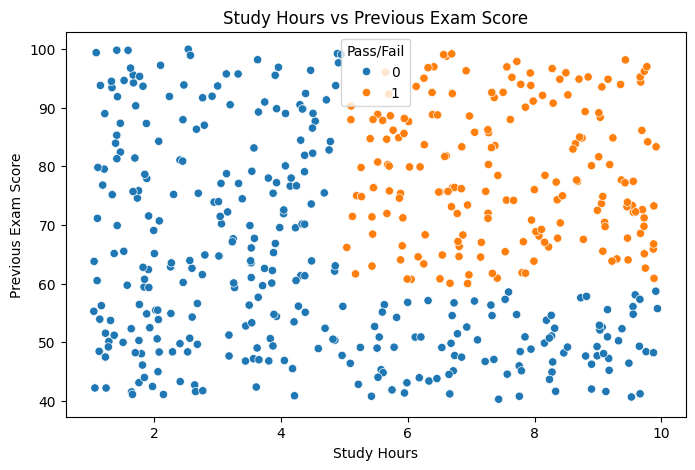

In [14]:
# Study Hours vs Previous Exam Score
plt.figure(figsize=(8,5))
sns.scatterplot( x='Study Hours', y='Previous Exam Score', hue='Pass/Fail', data=df )
plt.title("Study Hours vs Previous Exam Score")
plt.show()

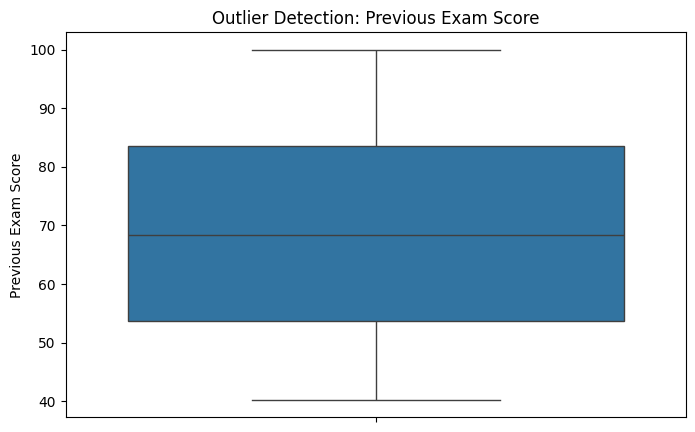

In [15]:
# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(y=df['Previous Exam Score'])
plt.title("Outlier Detection: Previous Exam Score")
plt.show()

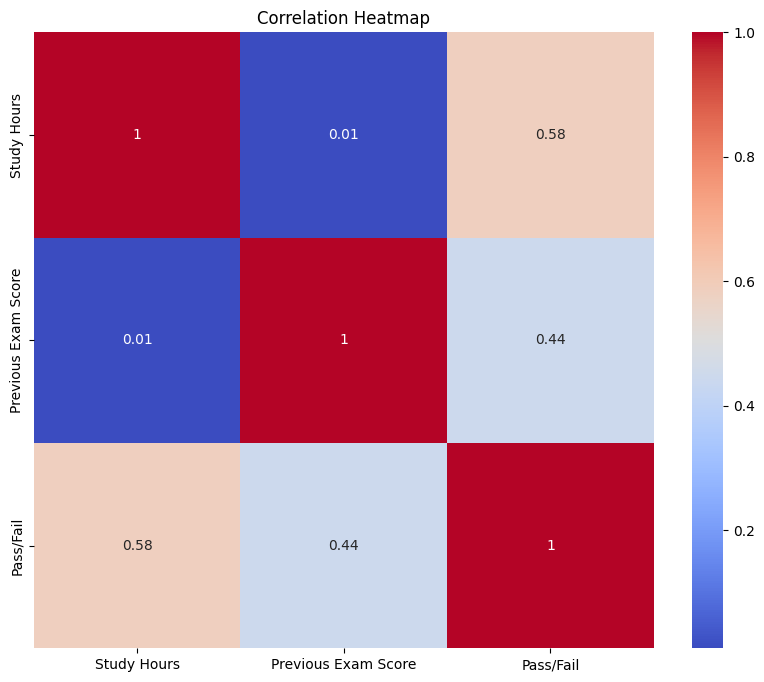

In [16]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [18]:
def risk_category(row):
  if (
      row['Study Hours'] < 5 and
      row['Previous Exam Score'] < 60
      ):
    return "High Risk"
  elif (
        row['Study Hours'] < 8 and
        row['Previous Exam Score'] < 75
        ):
      return "Medium Risk"
  else:
        return "Low Risk"
df['Risk_Category'] = df.apply(risk_category, axis=1)
print(df['Risk_Category'].value_counts())

Risk_Category
Low Risk       271
Medium Risk    150
High Risk       79
Name: count, dtype: int64


In [19]:
X = df.drop(['Pass/Fail', 'Risk_Category'], axis=1)
y = df['Pass/Fail']

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
x_train, X_test, y_train, y_test = train_test_split( X_scaled, y, test_size=0.2, random_state=42 )

In [21]:
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

In [23]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [24]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC Score:", roc_auc)

Accuracy: 0.86
Precision: 0.8235294117647058
Recall: 0.7777777777777778
F1 Score: 0.8
ROC AUC Score: 0.9301215277777778


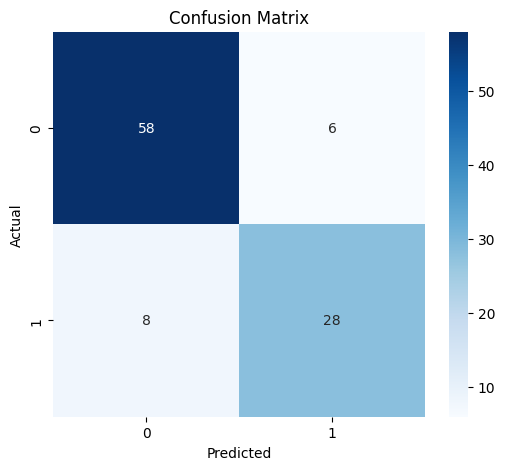

In [25]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89        64
           1       0.82      0.78      0.80        36

    accuracy                           0.86       100
   macro avg       0.85      0.84      0.85       100
weighted avg       0.86      0.86      0.86       100



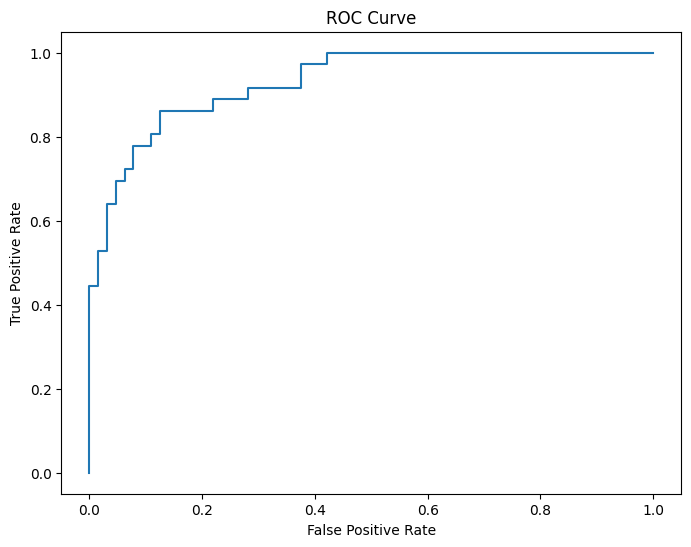

In [27]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [28]:
df.to_csv("cleaned_student_data.csv", index=False)
print("Project Completed Successfully")

Project Completed Successfully


In [32]:
import plotly.express as px

filtered_df = df

# Pass vs Fail
fig1 = px.histogram(
    filtered_df,
    x='Pass/Fail',
    color='Pass/Fail',
    title='Pass vs Fail Distribution' )
fig1.show() # Changed from st.plotly_chart(fig1)

# Study Hours Analysis
fig2 = px.scatter(
    filtered_df,
    x='Study Hours',
    y='Previous Exam Score',
    color='Pass/Fail',
    title='Study Hours vs Previous Exam Score' )
fig2.show() # Changed from st.plotly_chart(fig2)

In [36]:
import plotly.express as px

# Define filtered_df. Assuming it should be the main dataframe if no specific filtering logic is provided.
filtered_df = df

# Attendance Analysis
fig3 = px.scatter(
    filtered_df,
    x='Study Hours', # Corrected column name from 'Attendance_Rate'
    y='Previous Exam Score', # Corrected column name from 'Final_Exam_Score'
    color='Pass/Fail',
    title='Study Hours vs Previous Exam Score' )
fig3.show() # Changed from st.plotly_chart(fig3) for Colab environment

# Risk Category
fig4 = px.pie(
    filtered_df,
    names='Risk_Category',
    title='Student Risk Categories' )
fig4.show() # Changed from st.plotly_chart(fig4) for Colab environment
# st.success("Dashboard Loaded Successfully") # Commented out as 'st' is not defined in this Colab context

